# Kompas TV YouTube Sentiment Analysis

This project analyzes and compares the sentiment of YouTube comments from two different types of Kompas TV content:

1. A YouTube Short
2. A news video

The comments are collected using `yt-dlp`, processed using Indonesian text preprocessing techniques, and classified into positive, negative, and neutral sentiment using an Indonesian RoBERTa-based sentiment classifier.

## 1. Project Overview

The purpose of this analysis is to compare audience sentiment across two different types of YouTube content published by Kompas TV.

The analysis focuses on:

- Collecting YouTube comments
- Cleaning Indonesian text
- Tokenization
- Stopword removal
- Indonesian stemming
- Sentiment classification
- Comparing sentiment distributions
- Analyzing frequently occurring words
- Visualizing word frequencies using WordCloud

## 2. Setup & Dependencies

The project uses Python libraries for data collection, Indonesian text preprocessing, sentiment classification, and visualization.

In [1]:
# Install dependencies when running in Google Colab.
# If the packages are already installed, this cell can be skipped.

!pip install -q yt-dlp pandas nltk Sastrawi wordcloud matplotlib transformers torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.8 MB/s eta 0:00:00


In [2]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import yt_dlp

from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from transformers import pipeline
from wordcloud import WordCloud, STOPWORDS

## 3. Data Collection

YouTube comments are collected from two Kompas TV videos using `yt-dlp`.

The two videos represent different content formats:

- Video 1: YouTube Short
- Video 2: News Video

### 3.1 Video 1 — YouTube Short

**Title:** Megawati: Kalau Aku Mau Selfie, Pengikutku Pasti 'Akeh'

**Video ID:** `5m31aKW6VyM`

In [3]:
ydl_opts = {
    "skip_download": True,
    "getcomments": True,
}

def extract_comments(video_url):
    comments = []

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(video_url, download=False)

        for comment in info.get("comments", []):
            if comment.get("text"):
                comments.append(comment["text"])

    return comments

In [4]:
video1_url = "https://youtube.com/shorts/5m31aKW6VyM"

comments1 = extract_comments(video1_url)

df1 = pd.DataFrame({
    "text": comments1,
    "video": "video_1"
})

print(f"Video 1 comments: {len(df1):,}")

[youtube] Extracting URL: https://youtube.com/shorts/5m31aKW6VyM
[youtube] 5m31aKW6VyM: Downloading webpage


[youtube] 5m31aKW6VyM: Downloading visionos player API JSON
[youtube] 5m31aKW6VyM: Downloading m3u8 information
[youtube] Downloading comment section API JSON
[youtube] Downloading ~15110 comments
[youtube] Sorting comments by newest
[youtube] Downloading comment API JSON page 1 (0/~15110)
[youtube] Downloading comment API JSON page 2 (20/~15110)
[youtube] Downloading comment API JSON page 3 (40/~15110)
[youtube] Downloading comment API JSON page 4 (60/~15110)
[youtube] Downloading comment API JSON page 5 (80/~15110)
[youtube] Downloading comment API JSON page 6 (100/~15110)
[youtube] Downloading comment API JSON page 7 (120/~15110)
[youtube] Downloading comment API JSON page 8 (140/~15110)
[youtube] Downloading comment API JSON page 9 (160/~15110)
[youtube] Downloading comment API JSON page 10 (180/~15110)
[youtube] Downloading comment API JSON page 11 (200/~15110)
[youtube] Downloading comment API JSON page 12 (220/~15110)
[youtube] Downloading comment API JSON page 13 (240/~15110)
[

### 3.2 Video 2 — News Video

**Title:** Pengakuan Sopir Ambulans Saat Evakuasi Jenazah Brigadir J

**Video ID:** `ZriDaJlL0lU`

In [5]:
video2_url = "https://youtu.be/ZriDaJlL0lU"

comments2 = extract_comments(video2_url)

df2 = pd.DataFrame({
    "text": comments2,
    "video": "video_2"
})

print(f"Video 2 comments: {len(df2):,}")

[youtube] Extracting URL: https://youtu.be/ZriDaJlL0lU
[youtube] ZriDaJlL0lU: Downloading webpage


[youtube] ZriDaJlL0lU: Downloading visionos player API JSON
[youtube] ZriDaJlL0lU: Downloading m3u8 information
[youtube] Downloading comment section API JSON
[youtube] Downloading ~8023 comments
[youtube] Sorting comments by newest
[youtube] Downloading comment API JSON page 1 (0/~8023)
[youtube]     Downloading comment API JSON reply thread 1 (2/~8023)
[youtube]     Downloading comment API JSON reply thread 2 (11/~8023)
[youtube]     Downloading comment API JSON reply thread 3 (14/~8023)
[youtube]     Downloading comment API JSON reply thread 4 (18/~8023)
[youtube] Downloading comment API JSON page 2 (24/~8023)
[youtube]     Downloading comment API JSON reply thread 1 (27/~8023)
[youtube] Downloading comment API JSON page 3 (46/~8023)
[youtube]     Downloading comment API JSON reply thread 1 (48/~8023)
[youtube] Downloading comment API JSON page 4 (67/~8023)
[youtube] Downloading comment API JSON page 5 (87/~8023)
[youtube] Downloading comment API JSON page 6 (107/~8023)
[youtube]   

## 4. Data Preparation

The comments from both videos are combined into a single DataFrame for further analysis.

The source video is retained in the `video` column so that sentiment distributions can later be compared between the two videos.

In [6]:
df = pd.concat([df1, df2], ignore_index=True)

df = df.dropna(subset=["text"]).reset_index(drop=True)

print(f"Total comments: {len(df):,}")
print("\nComments by video:")
print(df["video"].value_counts())

df.head()

Total comments: 23,127

Comments by video:
video
video_1    15107
video_2     8020
Name: count, dtype: int64


,text,video
0,9?6!!-66!!!66⁶-6!!6-!!!6!!!6!!6⁶-6!!6!!6,video_1
1,Ngomong apa ini nenek?? 😊,video_1
2,Sak karepmu,video_1
3,Kok ora duwe isin yo,video_1
4,Karismatik ndasmu kui😂😂😂 badut,video_1


## 5. Text Preprocessing

The comments are preprocessed before sentiment classification.

The preprocessing pipeline consists of:

1. Text cleaning
2. Tokenization
3. Indonesian stopword removal
4. Indonesian stemming using Sastrawi

### 5.1 Text Cleaning

The cleaning process:

- Removes URLs
- Removes emojis and non-ASCII characters
- Removes symbols and numbers
- Converts text to lowercase
- Removes unnecessary whitespace

In [7]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^\x00-\x7F]+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["cleaning"] = df["text"].apply(clean_text)

df[["text", "cleaning"]].head()

,text,cleaning
0,9?6!!-66!!!66⁶-6!!6-!!!6!!!6!!6⁶-6!!6!!6,
1,Ngomong apa ini nenek?? 😊,ngomong apa ini nenek
2,Sak karepmu,sak karepmu
3,Kok ora duwe isin yo,kok ora duwe isin yo
4,Karismatik ndasmu kui😂😂😂 badut,karismatik ndasmu kui badut


### 5.2 Tokenization

The cleaned text is split into individual words.

In [8]:
df["tokens"] = df["cleaning"].apply(str.split)

df[["cleaning", "tokens"]].head()

,cleaning,tokens
0,,[]
1,ngomong apa ini nenek,"[ngomong, apa, ini, nenek]"
2,sak karepmu,"[sak, karepmu]"
3,kok ora duwe isin yo,"[kok, ora, duwe, isin, yo]"
4,karismatik ndasmu kui badut,"[karismatik, ndasmu, kui, badut]"


### 5.3 Indonesian Stopword Removal

Indonesian stopwords are removed using the NLTK Indonesian stopword list.

The words `tidak` and `bukan` are retained because they can affect sentence meaning and sentiment polarity.

In [9]:
nltk.download("stopwords")

stop_words = set(stopwords.words("indonesian"))

# Retain negation words because they can affect sentiment meaning.
stop_words.discard("tidak")
stop_words.discard("bukan")

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df["tokens"] = df["tokens"].apply(remove_stopwords)

df[["cleaning", "tokens"]].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,cleaning,tokens
0,,[]
1,ngomong apa ini nenek,"[ngomong, nenek]"
2,sak karepmu,"[sak, karepmu]"
3,kok ora duwe isin yo,"[ora, duwe, isin, yo]"
4,karismatik ndasmu kui badut,"[karismatik, ndasmu, kui, badut]"


### 5.4 Indonesian Stemming

Sastrawi is used to convert Indonesian words into their root forms.

In [10]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

df["stemming"] = df["tokens"].apply(
    lambda tokens: [stemmer.stem(word) for word in tokens]
)

df["text_clean"] = df["stemming"].apply(
    lambda tokens: " ".join(tokens)
)

df[["text", "text_clean"]].head()

,text,text_clean
0,9?6!!-66!!!66⁶-6!!6-!!!6!!!6!!6⁶-6!!6!!6,
1,Ngomong apa ini nenek?? 😊,ngomong nenek
2,Sak karepmu,sak karepmu
3,Kok ora duwe isin yo,ora duwe isin yo
4,Karismatik ndasmu kui😂😂😂 badut,karismatik ndasmu kui badut


## 6. Sentiment Classification

Sentiment classification is performed using the pretrained Indonesian RoBERTa sentiment classifier:

`w11wo/indonesian-roberta-base-sentiment-classifier`

Each comment is classified into:

- Positive
- Negative
- Neutral

In [11]:
sentiment_model = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier"
)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/808k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/467k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [12]:
def get_sentiment(text):
    try:
        result = sentiment_model(text[:512])[0]
        label = result["label"]

        if label == "positive":
            return "Positif"
        elif label == "negative":
            return "Negatif"
        else:
            return "Netral"

    except Exception:
        return "Netral"

df["Sentiment"] = df["text_clean"].apply(get_sentiment)

df[["text", "text_clean", "Sentiment"]].head()

,text,text_clean,Sentiment
0,9?6!!-66!!!66⁶-6!!6-!!!6!!!6!!6⁶-6!!6!!6,,Netral
1,Ngomong apa ini nenek?? 😊,ngomong nenek,Negatif
2,Sak karepmu,sak karepmu,Negatif
3,Kok ora duwe isin yo,ora duwe isin yo,Negatif
4,Karismatik ndasmu kui😂😂😂 badut,karismatik ndasmu kui badut,Netral


## 7. Sentiment Distribution

The overall distribution of sentiment across all collected comments is examined before comparing the two videos.

In [13]:
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Negatif    14324
Netral      5251
Positif     3552
Name: count, dtype: int64


## 8. Comparison Between Videos

The sentiment distribution is compared between Video 1 and Video 2 using both comment counts and percentages.

In [14]:
sentiment_by_video = pd.crosstab(
    df["video"],
    df["Sentiment"]
)

print(sentiment_by_video)

Sentiment  Negatif  Netral  Positif
video                              
video_1      10749    3049     1309
video_2       3575    2202     2243


In [15]:
sentiment_percentage = (
    df.groupby("video")["Sentiment"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

print(sentiment_percentage)

video    Sentiment
video_1  Negatif      71.15
         Netral       20.18
         Positif       8.66
video_2  Negatif      44.58
         Positif      27.97
         Netral       27.46
Name: proportion, dtype: float64


## 9. Sentiment Visualization

A stacked bar chart is used to compare the number of positive, neutral, and negative comments between the two videos.

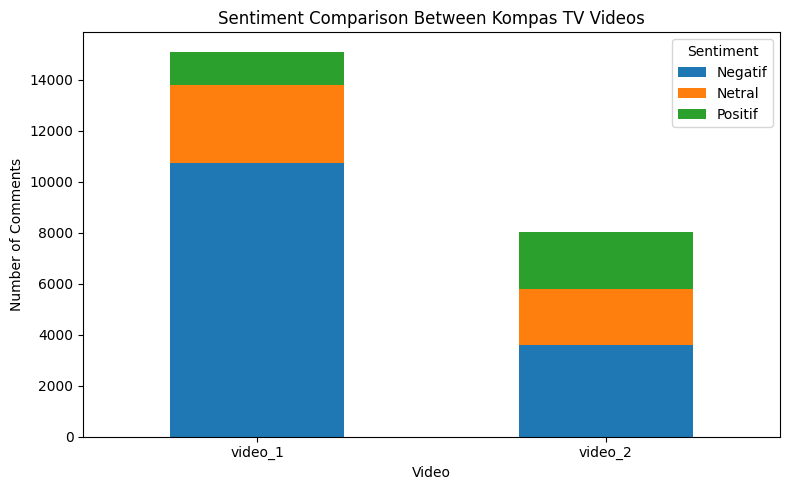

In [16]:
ax = sentiment_by_video.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

ax.set_title("Sentiment Comparison Between Kompas TV Videos")
ax.set_xlabel("Video")
ax.set_ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Word Frequency Analysis

The most frequently occurring words are calculated separately for each video.

Several common words that are not useful for interpretation are removed using a custom stopword list.

In [17]:
custom_stopwords = {
    "yang", "dan", "di", "ke", "dari",
    "ini", "itu", "nya", "aja", "ya",
    "ga", "gak", "nggak", "kompas", "tv"
}

for video in df["video"].unique():
    text = " ".join(
        df.loc[df["video"] == video, "cleaning"]
    ).lower()

    tokens = [
        word for word in text.split()
        if word not in custom_stopwords
    ]

    top_words = Counter(tokens).most_common(10)

    print(f"\nTop 10 words - {video}")
    for word, count in top_words:
        print(f"{word}: {count}")


Top 10 words - video_1
yg: 1968
nenek: 1364
sombong: 1034
orang: 1030
sendiri: 900
diri: 851
bu: 837
ada: 745
kok: 645
tua: 613

Top 10 words - video_2
jujur: 2225
yg: 2021
sopir: 1248
semoga: 939
mas: 919
supir: 912
orang: 899
allah: 888
sambo: 884
dia: 725


## 11. WordCloud

WordCloud is generated separately for each video to visualize frequently occurring words.

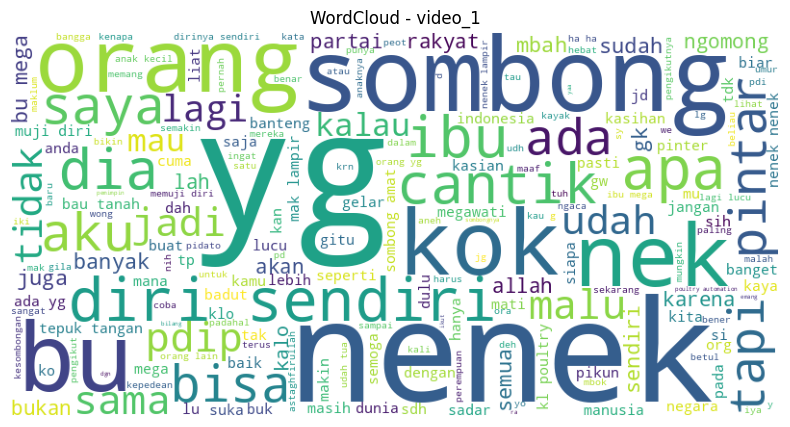

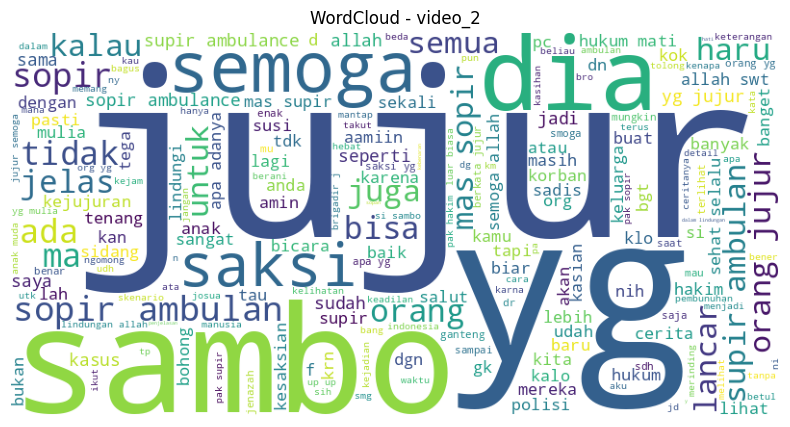

In [18]:
for video in df["video"].unique():
    text = " ".join(
        df.loc[df["video"] == video, "cleaning"]
    ).lower()

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        stopwords=custom_stopwords
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"WordCloud - {video}")
    plt.show()

## 12. Export Results

The final sentiment classification results can be exported as CSV for further analysis.

The files are generated locally when the notebook is executed and are not required to be committed to the GitHub repository.

In [19]:
df.to_csv("hasil_sentimen_kompas_tv.csv", index=False)

df[df["video"] == "video_1"].to_csv(
    "video1_sentimen.csv", index=False
)

df[df["video"] == "video_2"].to_csv(
    "video2_sentimen.csv", index=False
)

print("Export completed.")

Export completed.


## 13. Conclusion

The sentiment analysis shows that negative sentiment dominates the comments across both Kompas TV videos.

Video 1 has a substantially higher proportion of negative comments than Video 2, while Video 2 has a more balanced distribution of positive, neutral, and negative comments.

These results indicate differences in audience sentiment patterns between the two selected videos. However, the analysis is limited to two videos and should not be interpreted as evidence that video type directly causes differences in audience sentiment.

The project demonstrates the application of Indonesian text preprocessing and pretrained transformer-based sentiment classification to YouTube comment data.